# EDA : Dataset BTGenBot

Ce notebook est le document de référence décisionnel pour la suite du projet. Il servira de socle au fine-tuning d'un LLM compact pour la génération de Behavior Trees XML dans un cadre contraint

## Rappel

Suite à la transition de notre cadre initial vers une architecture inspirée de BTGenBot + Nav2, il nous a fallu évaluer si ce nouveau dataset était exploitable pour entraîner un modèle capable de comprendre une mission décrite en langage naturel par un opérateur et produire un template Behavior Tree XML paramétré et conforme à un domaine contraint

## Ce que ce notebook contient

1. La qualité du dataset (parsabilité, longueurs, propreté).
2. Les métriques structurelles, syntaxiques et sémantiques (nœuds, profondeur, complexité, vocabulaire BT, attributs, ports, catégories métier, motifs, lien texte ↔ structure ).
3. Les interprétations consolidées, les conclusions majeures et recommandations opérationnelles.
4. Une ouverture vers la modélisation par hypergraphes sémantiques / Graph RAG.

## 0. Chargement et utilitaires

On charge le dataset original (`bt_dataset.json`) et on définit un mini-pipeline de parsing XML résilient (fallback de sanitisation pour les défauts mineurs comme les doubles tirets dans les commentaires).

In [1]:
import json
import re
import math
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
plt.style.use('default')

def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'dataset' / 'bt_dataset.json').exists():
            return candidate
    raise FileNotFoundError('Impossible de trouver dataset/bt_dataset.json')

PROJECT_ROOT = find_project_root()
DATASET_PATH = PROJECT_ROOT / 'dataset' / 'bt_dataset.json'

with DATASET_PATH.open('r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)[['instruction', 'input', 'output']].copy()
print(f"Dataset : {DATASET_PATH}")
print(f"Nombre total d'exemples : {len(df)}")

Dataset : \\wsl.localhost\ubuntu-22.04\home\mlatoundji\studies\dev\nav4rails\repositories\BTGenBot_Nav4Rails\dataset\bt_dataset.json
Nombre total d'exemples : 594


In [2]:
def sanitize_xml(xml_text: str) -> str:
    cleaned = xml_text.strip().lstrip('\ufeff')
    cleaned = re.sub(r"<!--(.*?)-->", lambda m: '<!--' + m.group(1).replace('--', '-') + '-->', cleaned, flags=re.S)
    return cleaned

def parse_xml(xml_text):
    try:
        return ET.fromstring(xml_text), 'parsed', None
    except ET.ParseError:
        try:
            return ET.fromstring(sanitize_xml(xml_text)), 'parsed_sanitized', None
        except ET.ParseError as exc:
            return None, 'parse_error', str(exc)

def iter_nodes(root):
    rows, stack = [], [(root, 0)]
    while stack:
        node, depth = stack.pop()
        rows.append((node, depth))
        for child in reversed(list(node)):
            stack.append((child, depth + 1))
    return rows

## 1. Qualité du dataset : parsabilité et propreté

Avant toute métrique, on vérifie si chaque sortie XML peut être lue par un parseur standard. C'est l'indicateur le plus fondamental : un XML non parsable ne peut ni être validé, ni servir d'exemple supervisé pour un LLM censé produire du XML

In [ ]:
results = df['output'].apply(parse_xml)
df['parse_status'] = results.apply(lambda r: r[1])
df['parse_error'] = results.apply(lambda r: r[2])
df['xml_is_valid'] = df['parse_error'].isna()
df['root'] = results.apply(lambda r: r[0])

quality = pd.DataFrame({
    'count': df['xml_is_valid'].value_counts().rename({True: 'parsable', False: 'non_parsable'}),
})
quality['percent'] = (quality['count'] / len(df) * 100).round(2)
quality

,count,percent
xml_is_valid,,
parsable,578,97.31
non_parsable,16,2.69


Sur 594 exemples, 578 sont parsables (97,3 %) et 16 invalides (2,7 %). Les erreurs récurrentes sont des tokens XML mal formés et quelques balises non appariées. Ces 16 cas restent un signal de qualité utile : ils documentent les défauts typiques d'une génération non contrôlée et justifient une validation statique stricte avant exécution en simulation.

Pour le premier fine-tuning, on travaille sur le sous-ensemble parsable (578 exemples).

### Longueur des entrées et des sorties

Les longueurs conditionnent directement le budget de contexte du LLM et le risque de troncature. On regarde la longueur du prompt naturel et celle du XML cible.

In [ ]:
df['input_words'] = df['input'].str.split().str.len()
df['xml_chars'] = df['output'].str.len()
df['xml_lines'] = df['output'].str.count('\n') + 1

lengths = df[['input_words', 'xml_chars', 'xml_lines']].agg(['mean', 'median', 'min', 'max']).T.round(1)
lengths

,mean,median,min,max
input_words,114.7,117.5,29.0,172.0
xml_chars,2651.6,1080.0,131.0,31681.0
xml_lines,58.4,31.0,6.0,721.0


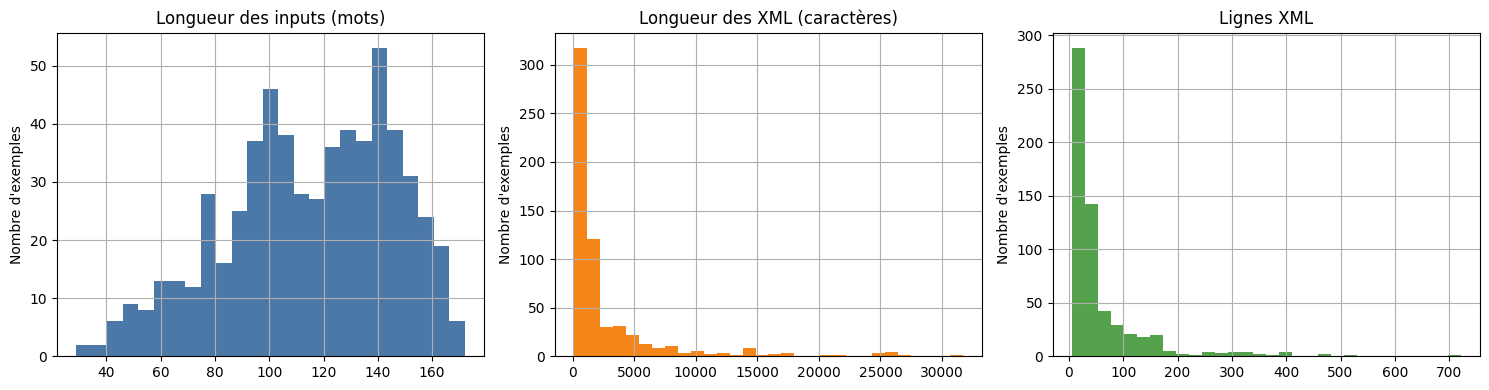

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['input_words'].hist(ax=axes[0], bins=25, color='#4C78A8')
axes[0].set_title('Longueur des inputs (mots)')
df['xml_chars'].hist(ax=axes[1], bins=30, color='#F58518')
axes[1].set_title('Longueur des XML (caractères)')
df['xml_lines'].hist(ax=axes[2], bins=30, color='#54A24B')
axes[2].set_title('Lignes XML')
for ax in axes:
    ax.set_ylabel("Nombre d'exemples")
plt.tight_layout()
plt.show()

Les inputs sont homogènes (médiane ≈ 117 mots). Les XML sont en revanche très asymétriques : la médiane est autour de 1 080 caractères / 30 lignes, mais quelques BT atteignent plus de 30 000 caractères ou 720 lignes. La difficulté pour le modèle sera donc surtout sur la génération XML, pas sur la compréhension de l'instruction. 

Il faudra segmenter le corpus par complexité, et fixer une politique pour les très longs BT (filtrage, troncature ciblée, ou allocation d'un budget de contexte étendu).

## 2. Métriques
### 2.1 Taille et complexité des arbres

Un Behavior Tree est un arbre orienté. On peut donc le caractériser par son nombre de nœuds, sa profondeur maximale et son facteur de branchement. Ces quantités prédisent la difficulté pour un LLM de générer la structure correctement.

On calcule en plus un score de complexité composite, qui combine taille, profondeur et largeur :

$$\text{complexity} = n\_\text{nodes} \cdot \log_2(\text{max\_depth} + 2) \cdot (\text{avg\_branching} + 1)$$

In [ ]:
metric_rows = []
for _, row in df[df['xml_is_valid']].iterrows():
    nodes = iter_nodes(row['root'])
    depths = [d for _, d in nodes]
    child_counts = [len(list(n)) for n, _ in nodes]
    internal = [c for c in child_counts if c > 0]
    n_nodes = len(nodes)
    max_depth = max(depths) if depths else 0
    avg_branching = float(np.mean(internal)) if internal else 0.0
    metric_rows.append({
        'n_nodes': n_nodes,
        'max_depth': max_depth,
        'avg_branching': avg_branching,
        'n_leaves': sum(1 for c in child_counts if c == 0),
        'complexity': n_nodes * math.log2(max_depth + 2) * (avg_branching + 1),
    })
df_metrics = pd.DataFrame(metric_rows)
df_metrics.describe().round(2).T[['mean', '50%', 'min', 'max']].rename(columns={'50%': 'median'})

,mean,median,min,max
n_nodes,37.24,16.00,3.0,399.00
max_depth,5.40,5.00,2.0,21.00
avg_branching,2.27,2.00,1.0,9.00
n_leaves,23.80,9.00,1.0,255.00
complexity,457.20,150.86,12.0,5649.23


In [7]:
def bucket(n):
    if n <= 20: return 'simple_<=20'
    if n <= 60: return 'moyen_21_60'
    return 'complexe_>60'

buckets = df_metrics['n_nodes'].apply(bucket).value_counts()
buckets_df = buckets.rename_axis('complexity_bucket').reset_index(name='count')
buckets_df['percent'] = (buckets_df['count'] / len(df_metrics) * 100).round(2)
buckets_df

,complexity_bucket,count,percent
0,simple_<=20,343,59.34
1,moyen_21_60,137,23.70
2,complexe_>60,98,16.96


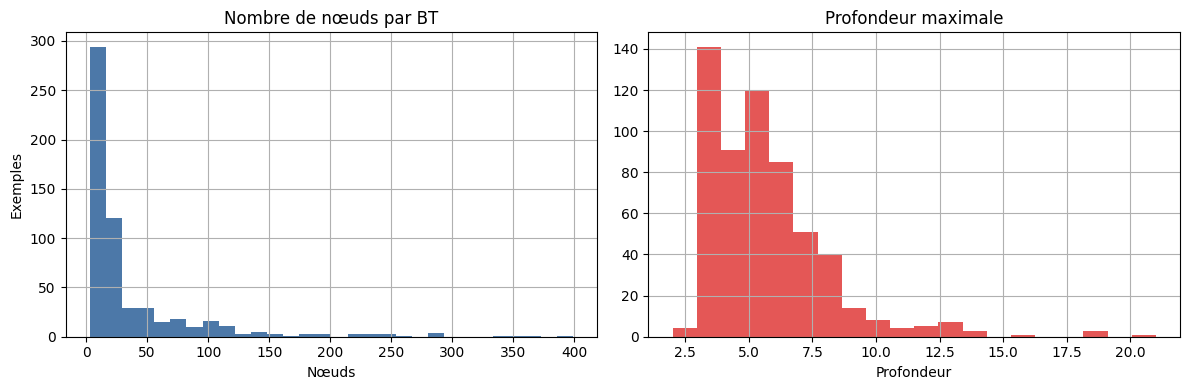

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_metrics['n_nodes'].hist(ax=axes[0], bins=30, color='#4C78A8')
axes[0].set_title('Nombre de nœuds par BT')
axes[0].set_xlabel('Nœuds'); axes[0].set_ylabel('Exemples')
df_metrics['max_depth'].hist(ax=axes[1], bins=20, color='#E45756')
axes[1].set_title('Profondeur maximale')
axes[1].set_xlabel('Profondeur')
plt.tight_layout(); plt.show()


- Médiane 16 nœuds, profondeur médiane 5 : la majorité des BT sont compacts.
- Max 399 nœuds, profondeur 21, complexité 5 649 : une longue traîne d'arbres très grands existe, souvent issue de scénarios génériques IA/jeu non alignés Nav2.
- ≈ 61 % simples, ≈ 27 % moyens, ≈ 9 % complexes : un fine-tuning naïf serait dominé par les BT simples et apprendrait mal les structures profondes ou les recovery imbriqués.

Il faudrait stratifier le dataset par bucket de complexité pendant l'entraînement et l'évaluation.

### 2.2 Vocabulaire BT, attributs, ports

Sous l'angle syntaxique, un Behavior Tree XML est un assemblage de :

- tags de contrôle (`Sequence`, `Fallback`, `Parallel`, `ReactiveSequence`...),
- décorateurs (`Retry`, `Repeat`, `Inverter`, `ForceFailure`...),
- actions / conditions (skills métier, parfois génériques `Action ID="..."`),
- attributs (`ID`, `name`, `goal`, `path`, `service_name`, paramètres numériques),
- ports typés (`input_port`, `output_port`, `inout_port`),
- variables Blackboard (`{goal}`, `{path}`...).

C'est la grammaire que le LLM doit apprendre à respecter

In [9]:
tag_counter = Counter()
attr_counter = Counter()
for root in df.loc[df['xml_is_valid'], 'root']:
    for element, _ in iter_nodes(root):
        tag_counter[element.tag] += 1
        for k in element.attrib:
            attr_counter[k] += 1

print(f"Nombre de tags XML uniques : {len(tag_counter)}")
print(f"Nombre d'attributs uniques : {len(attr_counter)}\n")
top_tags = pd.DataFrame(tag_counter.most_common(15), columns=['tag', 'count'])
top_tags

Nombre de tags XML uniques : 360
Nombre d'attributs uniques : 502



,tag,count
0,Action,5482
1,input_port,3137
2,Condition,1856
3,Sequence,1460
4,BehaviorTree,942
5,output_port,897
6,SubTree,773
7,Fallback,658
8,root,578
9,SetBlackboard,364


In [10]:
top_attrs = pd.DataFrame(attr_counter.most_common(15), columns=['attribute', 'count'])
top_attrs

,attribute,count
0,ID,9158
1,name,6828
2,type,1692
3,default,970
4,main_tree_to_execute,578
5,value,421
6,output_key,364
7,goal,349
8,path,349
9,service_name,317


In [11]:
BLACKBOARD_RE = re.compile(r'\{[A-Za-z_][A-Za-z0-9_./:-]*\}')
bb_counter = Counter()
for xml_text in df['output']:
    bb_counter.update(BLACKBOARD_RE.findall(xml_text))

print(f"Variables Blackboard distinctes : {len(bb_counter)}")
pd.DataFrame(bb_counter.most_common(10), columns=['blackboard_variable', 'count'])

Variables Blackboard distinctes : 307


,blackboard_variable,count
0,{path},305
1,{goal},161
2,{ltl_state_current},148
3,{bt_action_type},99
4,{current_action},83
5,{ltl_state_executed_sequence},77
6,{replanning_request},67
7,{ltl_state_desired_sequence},60
8,{manipulator_path},51
9,{said},47


- Tags dominants : `Action`, `Condition`, `Sequence`, `Fallback`, `SubTree`, `SetBlackboard`. On retrouve les briques classiques BehaviorTree.CPP v4.
- Attributs dominants : `ID`, `name`, `goal`, `path`, `service_name`, `planner_id`, `controller_id` 
- Blackboard : `{goal}`, `{path}` apparaissent massivement, confirmant que la circulation de variables entre nœuds est une compétence centrale.
- 314 à 1 310 nœuds uniques selon la granularité (tag seul ou `tag:ID`) → le vocabulaire métier est très ouvert.

Il faudra imposer des ports typés et des paramètres validables puis mettre en place le constrained decoding (GBNF) pour empêcher les hallucinations de tags.

### 2.3 Catégories, motifs, lien texte entre structure

Cette section est la plus utile pour décider comment structurer la chaîne de génération. On regarde les motifs structurels récurrents (sous-arbres N-grammes) et la force du lien entre description textuelle et topologie XML.

### 2.3.1 Catégories métier (multi-label par mots-clés)

On utilise une heuristique simple : la présence de mots-clés dans le texte attribue une ou plusieurs catégories à un exemple

In [12]:
CATEGORY_PATTERNS = {
    'navigation': [r'\bnavigat\w*\b', r'\bpath\b', r'\bplanner\b', r'\bgoal\b', r'\bwaypoint\b', r'\bcostmap\b'],
    'recovery_fallback': [r'\bfallback\b', r'\brecover\w*\b', r'\bretry\b', r'\btimeout\b'],
    'manipulation': [r'\bmanipulat\w*\b', r'\barm\b', r'\bpick\b', r'\bplace\b', r'\bgrasp\b'],
    'condition_logic': [r'\bcondition\b', r'\bcheck\b', r'\bif\b', r'\bvalid\b'],
    'parallel_loop': [r'\bparallel\b', r'\brepeat\b', r'\bloop\b', r'\bcontinuous\b'],
}

def categorize(input_text, output_text):
    text = f"{input_text}\n{output_text}".lower()
    cats = [c for c, pats in CATEGORY_PATTERNS.items() if any(re.search(p, text) for p in pats)]
    return cats or ['autre']

df['categories'] = df.apply(lambda r: categorize(r['input'], r['output']), axis=1)
cat_counter = Counter(c for cats in df['categories'] for c in cats)
cat_table = pd.DataFrame(cat_counter.most_common(), columns=['categorie', 'count'])
cat_table['percent'] = (cat_table['count'] / len(df) * 100).round(2)
cat_table

,categorie,count,percent
0,condition_logic,370,62.29
1,navigation,368,61.95
2,recovery_fallback,274,46.13
3,parallel_loop,182,30.64
4,manipulation,106,17.85
5,autre,57,9.60


La navigation domine (~62 %), suivie par les motifs de recovery (~46 %) et la logique conditionnelle. 
La manipulation est minoritaire. 

### 2.3.2 Motifs structurels récurrents

Les motifs "parent --> child" et les sous-arbres à profondeur 2 sont des briques réutilisables que le LLM peut apprendre comme des macros. C'est aussi la base d'une bibliothèque de patterns pour un futur Graph RAG

In [13]:
STRUCTURAL_NOISE = {'dummy_root', 'root', 'BehaviorTree', 'TreeNodesModel',
                    'Action', 'Condition', 'Control', 'Decorator',
                    'input_port', 'output_port', 'inout_port'}

def subtree_sig(element, depth=2):
    if depth <= 0 or len(list(element)) == 0:
        return element.tag
    children = [subtree_sig(c, depth - 1) for c in element if c.tag not in STRUCTURAL_NOISE]
    return f"{element.tag}({', '.join(children)})" if children else element.tag

fallback_patterns = Counter()
for root in df.loc[df['xml_is_valid'], 'root']:
    for element, _ in iter_nodes(root):
        if element.tag in {'Fallback', 'ReactiveFallback', 'RecoveryNode'}:
            fallback_patterns[subtree_sig(element, 2)] += 1

pd.DataFrame(fallback_patterns.most_common(10), columns=['recovery_pattern', 'count'])

,recovery_pattern,count
0,Fallback,85
1,Fallback(ForceFailure),52
2,Fallback(Sequence),46
3,"Fallback(Sequence, Sequence)",28
4,"RecoveryNode(FollowPath, ClearEntireCostmap)",26
5,Fallback(Sequence(Fallback)),26
6,Fallback(SequenceStar),24
7,"RecoveryNode(PipelineSequence(RateController, RecoveryNode), ReactiveFallback(GoalUpdated, SequenceStar))",23
8,"RecoveryNode(ComputePathToPose, ClearEntireCostmap)",21
9,"ReactiveFallback(GoalUpdated, SequenceStar(ClearEntireCostmap, ClearEntireCostmap, Spin, Wait))",21


Les recovery patterns les plus fréquents sont des structures mission sécurisée très réutilisables :

- Fallback(Sequence, Sequence) → essai → repli ;
- RecoveryNode(FollowPath, ClearEntireCostmap) → exécution + nettoyage du costmap si échec ;
- Fallback(Sequence(Fallback)) → recovery imbriqué.

Ces motifs sont des briques fondamentales pour NAV4RAIL et un excellent matériel pour la planification symbolique (chacun correspond à une intention métier : retry, fallback, recovery).

###  2.3.3 Lien entre texte et structure : peut-on prédire la topologie à partir du texte ?

C'est la question critique. Si le texte de la mission prédit fortement la structure XML, alors un modèle texte → XML direct est viable. Sinon, il faut une architecture multi-étapes avec planification intermédiaire.

In [14]:
KEYWORD_GROUPS = {
    'navigation': ['navigate', 'navigation', 'path', 'goal', 'planner', 'controller', 'move', 'pose'],
    'recovery': ['recover', 'recovery', 'retry', 'fallback', 'clear', 'costmap'],
    'object_manipulation': ['object', 'pick', 'place', 'grasp', 'arm'],
    'condition_logic': ['condition', 'check', 'if', 'valid', 'state'],
    'parallel_loop': ['parallel', 'repeat', 'loop', 'continuous', 'periodically'],
}

for group, kws in KEYWORD_GROUPS.items():
    pat = r'\b(' + '|'.join(re.escape(k) for k in kws) + r')\b'
    df[f'kw_{group}'] = df['input'].str.lower().str.count(pat)

valid = df[df['xml_is_valid']].copy().reset_index(drop=True)
valid = pd.concat([valid, df_metrics.reset_index(drop=True)], axis=1)

kw_cols = [c for c in valid.columns if c.startswith('kw_')]
struct_cols = ['n_nodes', 'max_depth', 'complexity']
corr = valid[kw_cols + struct_cols].corr().loc[kw_cols, struct_cols].round(2)
corr

,n_nodes,max_depth,complexity
kw_navigation,-0.22,0.10,-0.22
kw_recovery,-0.06,0.29,-0.08
kw_object_manipulation,0.05,-0.06,0.05
kw_condition_logic,0.09,0.30,0.09
kw_parallel_loop,-0.09,0.14,-0.10


Les corrélations entre les thèmes textuels et les caractéristiques structurelles sont faibles (typiquement |r| ≤ 0,31)

Un pipeline texte brut → XML est fragile. La voie viable est une chaîne multi-étapes :

1. **extraction d'intention** depuis le texte,
2. **planification structurée** (sélection de motifs),
3. **retrieval** de motifs similaires (Graph RAG),
4. **génération XML contrainte** (constrained decoding),
5. **validation statique** (L1 syntaxique → L2 structurel → L3 sémantique métier) **avant simulation**.

## 3. Conclusions majeures

1. **Le dataset est exploitable, mais c'est un socle, pas une cible.** 578 BT parsables (97,3 %), médiane 16 nœuds / profondeur 5, vocabulaire BT.CPP riche. Il faut le **nettoyer, segmenter, enrichir et raccorder à un validateur** avant d'en faire une base d'entraînement fiable pour NAV4RAIL.

2. **La navigation est dominante (~62 à 85 % selon mesure).** Cela aligne le corpus avec NAV4RAIL, mais ~15 à 38 % du corpus relève d'autres domaines (jeux, scénarios IA, manipulation) qui introduiront du **bruit** pour un objectif ferroviaire strict.

3. **Le texte ne prédit pas la topologie.** Corrélations |r| ≤ 0,31 et similarité cosinus texte ↔ structure ≈ 0,18. Un pipeline texte → XML direct est fragile.

4. **Les recovery patterns sont structurés et réutilisables.** `Fallback(Sequence, Sequence)`, `RecoveryNode(FollowPath, ClearEntireCostmap)` et leurs variantes constituent des **briques réutilisables** pour la génération contrôlée.

5. **Le vocabulaire est ouvert (314 à 1 310 nœuds uniques selon granularité).** L'écart avec le catalogue NAV4RAIL fermé (28 skills) est important. Il faut une **allowlist** stricte et un **constrained decoding** dès la génération.

6. **Les 16 XML invalides sont un signal de qualité.** Ils documentent les défauts typiques d'une génération non contrôlée et **justifient la pile L1 / L2 / L3** déjà prévue dans la stratégie.

## 4. Recommandations opérationnelles

### 4.1 Préparation du dataset

- **Filtrer** les 16 XML non parsables pour la phase 1 du fine-tuning.
- **Stratifier** l'apprentissage et l'évaluation par bucket de complexité (`simple ≤ 20`, `moyen 21–60`, `complexe > 60`).
- **Enrichir chaque exemple** avec des métadonnées EDA (n_nodes, max_depth, complexity, catégories, motifs dominants, statut de parsing).
- **Séparer audit et entraînement** : un JSONL `all_with_status` pour le diagnostic, un JSONL `clean_parsable` pour QLoRA.

### 4.2 Architecture de génération (stratégie GraphRAG uniquement)

Adopter une chaîne en plusieurs étages plutôt qu'un mapping direct texte → XML :

1. **Extraction d'intention** (NLU sur la mission opérateur).
2. **Planification symbolique** sur le catalogue de 28 skills NAV4RAIL.
3. **Retrieval** de motifs structurels similaires (Graph RAG).
4. **Génération XML contrainte** (GBNF / token masking).
5. **Validation déterministe** L1 syntaxique → L2 structurel (schéma BT) → L3 sémantique (règles métier / ports / Blackboard).
6. **Simulation** (optionnel) seulement après que la validation a réussi.

### 4.3 Évaluation

- Conformité L1 / L2 / L3 séparée et reportée comme métrique principale.
- Score sémantique sur tâches métier reproductibles (missions hors dataset).
- Catalogue des modes d'échec récurrents (Fallback manquant, SubTree non défini, port mal typé, variable Blackboard absente).

### 4.4 Fine-tuning (et alignement?)

- **Phase 1 — SFT QLoRA NF4 ** sur le sous-ensemble clean parsable, pour faire apprendre la **syntaxe BT.CPP** générique.
- **Phase 2 (optionnel ou si applicable) — alignement par préférences (PPO/RLHF) ou RLVR** avec un reward basé sur la validation déterministe (L1/L2/L3).

### 4.5 Politique sur les BT extrêmes

- Les BT à plus de 60 nœuds représentent ~10 % du corpus mais sont souvent dominés par des `TreeNodesModel`. Décider explicitement :
  - les **inclure** pour exposer le modèle à des structures riches ;
  - ou les **traiter à part** dans un second tour de boucle.

## 5. Ouverture : hypergraphes sémantiques et Graph RAG

Au-delà du couple `(input texte, output XML)`, l'analyse fait émerger une représentation plus riche qui pourrait devenir la **couche pivot** entre intention et XML : un **graphe sémantique documenté**, voire un **hypergraphe**.

### Pourquoi un hypergraphe

Un Behavior Tree mobilise plusieurs types d'entités qui interagissent **plus que par paires** :

- **intentions** (mission opérateur, sous-objectifs),
- **actions / conditions** (les 28 skills NAV4RAIL),
- **ports typés** (input, output, inout) et **variables Blackboard** (`{goal}`, `{path}`, ...),
- **contraintes de validation** (L1 / L2 / L3 — schéma, règles métier, sécurité),
- **motifs BT réutilisables** (`Fallback(Sequence, Sequence)`, `RecoveryNode(FollowPath, ClearEntireCostmap)`, ...).

Une **hyperarête** peut alors capturer un motif composé comme `(intention X) + (action Y) + (recovery Z) + (port `goal`)` en un seul objet, là où des arêtes binaires perdent ce contexte multi-acteurs.

### Ce qu'apporterait un Graph RAG

- **Retrieval structuré** : pour une mission donnée, retrouver les motifs déjà éprouvés.
- **Planification symbolique** : composer des motifs avant de générer du XML.
- **Génération contrôlée** : le LLM reçoit en contexte des nœuds et hyperarêtes typés, ce qui réduit drastiquement la surface d'hallucination.
- **Validation traçable** : chaque assemblage peut être audité sur les contraintes de l'hypergraphe avant production XML.